# Visualizing the data captured
This script will allow you to visualise the data you captured (or were given). At the end you will have a 1D plot (in other words the Range FFT) giving you the change in frequencies in the x axis and the power at which those frequencies are on the y axis. The change (or delta) in frequencies will enable you to estimate the range at which the object was from the radar, whereas the power allows you to understand the strength of the reflector. The strength can be impacted by many things such as the material (something like metal will reflect much more of the signal than something like plastic), the size, and shape of the reflector!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import sys

sys.path.append(os.path.dirname(os.getcwd()))

import utils.save_adc_data as sd
import utils.utility as utility


## Finding your way to the data
This part allow you to specify where all the **data** is located in your file system, relative to where this file (visualize_data.ipynb) is saved.
* *filename* must correspond to the name of the **experiment** you made (it is the same as the one you had to setup in the config file)
* *capture_data_dir* must correspond to the folder were you stored the **raw data** captured by the radar (aka the *.bin file)
* *json_filename* correspond to the the json file that we provide for you, it describes the paramters that you captured the data, such as number of frames, number of transmitters, number of receivers, number of ADC samples, etc. 
* *config_lua_script* is the configuration lua script (same as capture_data.ipynb)

**IMPORTANT NOTE** 
If you decide to change something about the chirp parameters (primarily number of Tx, number of Rx, or ADC samples) then you must do some extra edits below to reformat the data accordingly. Otherwise leave the defaults.




In [2]:
filename = r"highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128"
home_dir = r"D:/GitHub/COM-304-Rat-Detection"
capture_data_dir = r"data/rat-data/20-4-26/rat-raw"
json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config.lua' 


path_to_rawdata = os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')
if os.path.exists(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')):
    bin_data = sio.loadmat(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat'))

# this function reads the parameters from your lua config file (look at this function to see how it expects your config file to be formatted)
chirp_dict = utility.read_radar_params(os.path.join(home_dir,config_lua_script))

tx_en = '0x7' # HEX enable (1 for on, 0 for off)
rx_en = '0xF' # HEX enable (1 for on, 0 for off)

args = [chirp_dict['num_tx'], chirp_dict['num_rx'], chirp_dict['samples_per_chirp'], chirp_dict['chirp_loops'], tx_en, rx_en]

This cells calls to another script that you have called save_adc_data, located in the **processing** folder. What this script does it reformating the data, which is a binary file, to a more understandable format which it a .mat {}

In [3]:
############################# Reformat the Data #############################
if not os.path.exists(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')):
    sd.save_adc_data(filename, home_dir, capture_data_dir, json_filename,args)

In [20]:
################################# load data #################################
bin_data = sio.loadmat(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat'))
raw_data = np.array(bin_data['data_raw'])
print("You captured %d frames, for %d TX, %d Rx, and %d adc samples" % raw_data.shape)

You captured 5 frames, for 3 TX, 4 Rx, and 512 adc samples


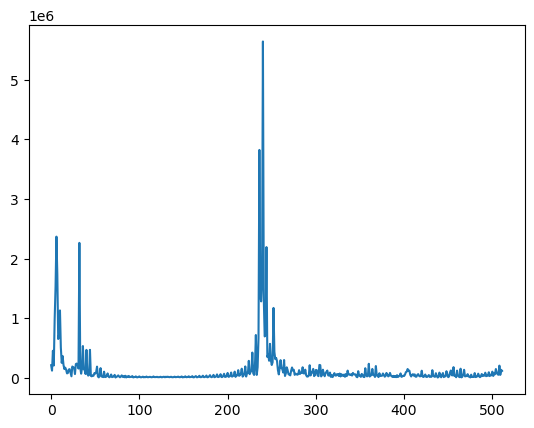

In [21]:
############################### process data! ################################
# Range FFT
rfft = scipy.fft.fft(raw_data, axis=3)

# Plot the Range FFT
plt.plot(abs(np.squeeze(np.sum(rfft,axis=(0,2,1)))))


# RAT DETECTION TESTING

In [ ]:
# setup
filename = r""
home_dir = r"D:/GitHub/COM-304-Rat-Detection"

raw_pipe_capture_data_dir = r"data/pipe-data/20-4-26/pipe-raw"
full_pipe_capture_data_dir = r"data/pipe-data/20-4-26/full-pip"
json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config_highres.lua' 


def create_file_path(data_dir, filename):
    path = os.path.join(home_dir, data_dir, "rdc_" + filename + '.mat')
    return path


def save_adc_data(path, filename, home_dir, data_dir, json_filename, args):
    if not os.path.exists(path):
        sd.save_adc_data(filename, home_dir, data_dir, json_filename,args)

def load_adc_data(path):
    bin_data = sio.loadmat(path)
    raw_data = np.array(bin_data['data_raw'])
    return raw_data

def read_lua_config(lua):
    # this function reads the parameters from your lua config file (look at this function to see how it expects your config file to be formatted)
    chirp_dict = utility.read_radar_params(os.path.join(home_dir,lua))

    tx_en = '0x7' # HEX enable (1 for on, 0 for off)
    rx_en = '0xF' # HEX enable (1 for on, 0 for off)

    args = [chirp_dict['num_tx'], chirp_dict['num_rx'], chirp_dict['samples_per_chirp'], chirp_dict['chirp_loops'], tx_en, rx_en]

    return args


In [33]:
args = read_lua_config(config_lua_script)

In [60]:
# read raw rat data
raw_rat_capture_data_dir = r"data/rat-data/20-4-26/rat-raw"

jerry_name = "highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128"
jerry_path = create_file_path(raw_rat_capture_data_dir, jerry_name)
if os.path.exists(jerry_path):
    jerry_bin = sio.loadmat(jerry_path)

save_adc_data(jerry_path, jerry_name, home_dir, raw_rat_capture_data_dir, json_filename, args)
jerry_raw = load_adc_data(jerry_path)

jerry_rfft = scipy.fft.fft(jerry_raw, axis=3)

mike_name = "highres_rat_setup-michael_take-1_fs-2420_slp-62-474_N-128"
mike_path = create_file_path(raw_rat_capture_data_dir, mike_name)
if os.path.exists(mike_path):
    mike_bin = sio.loadmat(mike_path)
save_adc_data(mike_path, mike_name, home_dir, raw_rat_capture_data_dir, json_filename, args)
mike_raw = load_adc_data(mike_path)

mike_rfft = scipy.fft.fft(mike_raw, axis=3)


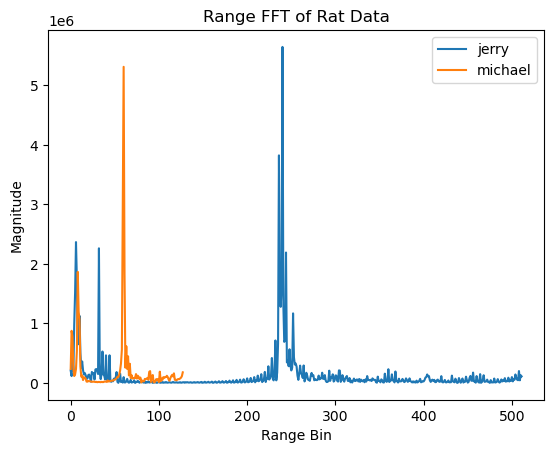

In [61]:
# Plot the rats FFT
plt.plot(abs(np.squeeze(np.sum(jerry_rfft,axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(mike_rfft,axis=(0,2,1)))))
plt.legend(['jerry', 'michael'])
plt.xlabel('Range Bin')
plt.ylabel('Magnitude')
plt.title('Range FFT of Rat Data')
plt.show()

In [ ]:
# capture raw pipe data
raw_pipe_capture_data_dir = r"data/rat-data/20-4-26/pipe-raw"

pipe1_name = ("highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128")
pipe1_path = create_file_path(raw_pipe_capture_data_dir, pipe1_name)
pipe2_path = create_file_path(raw_pipe_capture_data_dir, "highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128")
pipe3_path = create_file_path(raw_pipe_capture_data_dir, "highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128")
pipe4_path = create_file_path(raw_pipe_capture_data_dir, "highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128")
pipe5_path = create_file_path(raw_pipe_capture_data_dir, "highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128")

pipe_rfft = [0,0,0,0,0]
for i in range(1,6):

    name = f"highres_rat_setup-pipe_take-{i}_fs-2420_slp-62-474_N-128"
    path = create_file_path(raw_pipe_capture_data_dir, name)

    save_adc_data(path, name, home_dir, raw_pipe_capture_data_dir, json_filename, args)

    raw = load_adc_data(path)
    pipe_rfft[i-1] = scipy.fft.fft(raw, axis=3)

    print(name, raw.shape)


highres_rat_setup-pipe_take-1_fs-2420_slp-62-474_N-128 (40, 3, 4, 128)
highres_rat_setup-pipe_take-2_fs-2420_slp-62-474_N-128 (40, 3, 4, 128)
highres_rat_setup-pipe_take-3_fs-2420_slp-62-474_N-128 (20, 3, 4, 128)
highres_rat_setup-pipe_take-4_fs-2420_slp-62-474_N-128 (20, 3, 4, 128)
highres_rat_setup-pipe_take-5_fs-2420_slp-62-474_N-128 (20, 3, 4, 128)


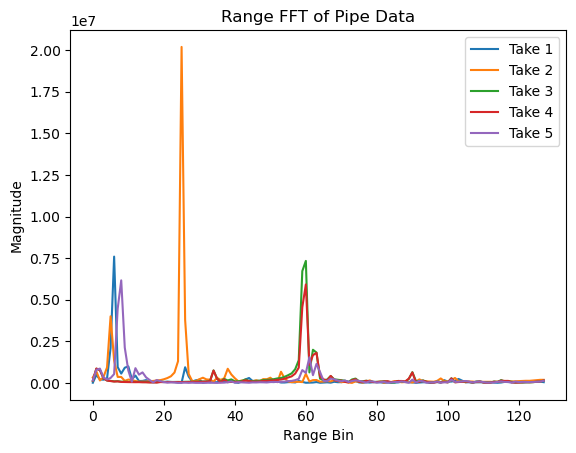

In [52]:
# plot the pipe data
for i in range(5):
    plt.plot(abs(np.squeeze(np.sum(pipe_rfft[i],axis=(0,2,1)))))

plt.legend(['Take 1', 'Take 2', 'Take 3', 'Take 4', 'Take 5'])
plt.xlabel('Range Bin')
plt.ylabel('Magnitude')
plt.title('Range FFT of Pipe Data')
plt.show()

In [57]:
# combined data
full_pipe_capture_data_dir = r"data/rat-data/20-4-26/full-pipe"

rubber_name  = "highres_rat_setup-piped-eraser-antenna-aligned_take-1_fs-2420_slp-62-474_N-128"
rubber_path = create_file_path(full_pipe_capture_data_dir, rubber_name)

jerry_pipe_name1 = "highres_rat_setup-piped-jerry_take-1_fs-2420_slp-62-474_N-128"
jerry_pipe_path1 = create_file_path(full_pipe_capture_data_dir, jerry_pipe_name1)
jerry_pipe_name2 = "highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128"
jerry_pipe_path2 = create_file_path(full_pipe_capture_data_dir, jerry_pipe_name2)
jerry_pipe_aligned_name = "highres_rat_setup-piped-jerry-antenna-aligned_take-3_fs-2420_slp-62-474_N-128" 
jerry_pipe_aligned_path = create_file_path(full_pipe_capture_data_dir, jerry_pipe_aligned_name)

if os.path.exists(rubber_path):
    rubber_bin = sio.loadmat(rubber_path)
save_adc_data(rubber_path, rubber_name, home_dir, full_pipe_capture_data_dir, json_filename, args)
raw_rubber = load_adc_data(rubber_path)
rubber_rfft = scipy.fft.fft(raw_rubber, axis=3)

jerry_piped_rfft = [0,0]
for i in range(1,3):
    name = f"highres_rat_setup-piped-jerry_take-{i}_fs-2420_slp-62-474_N-128"
    path = create_file_path(full_pipe_capture_data_dir, name)

    save_adc_data(path, name, home_dir, full_pipe_capture_data_dir, json_filename, args)

    raw = load_adc_data(path)
    jerry_piped_rfft[i-1] = scipy.fft.fft(raw, axis=3)

if os.path.exists(jerry_pipe_aligned_path):
    jerry_pipe_aligned_bin = sio.loadmat(jerry_pipe_aligned_path)

save_adc_data(jerry_pipe_aligned_path, jerry_pipe_aligned_name, home_dir, full_pipe_capture_data_dir, json_filename, args)
raw_jerry_pipe_aligned = load_adc_data(jerry_pipe_aligned_path)
jerry_pipe_aligned_rfft = scipy.fft.fft(raw_jerry_pipe_aligned, axis=3)




D:/GitHub/COM-304-Rat-Detection\data/rat-data/20-4-26/full-pipe\raw_highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128
D:/GitHub/COM-304-Rat-Detection\data/rat-data/20-4-26/full-pipe\rdc_highres_rat_setup-piped-jerry_take-2_fs-2420_slp-62-474_N-128
Input ADC data parameters:
    dataFmt: 1
    iqSwap: 0
    chanInterleave: 1
    numChirpsPerFrame: 3
    adcBits: 2
    numRxChan: 4
    numAdcSamples: 128
Radarcube parameters:
    iqSwap: 0
    radarCubeFmt: 1
    numDopplerChirps: 1
    numRxChan: 4
    numTxChan: 3
    numRangeBins: 128.0


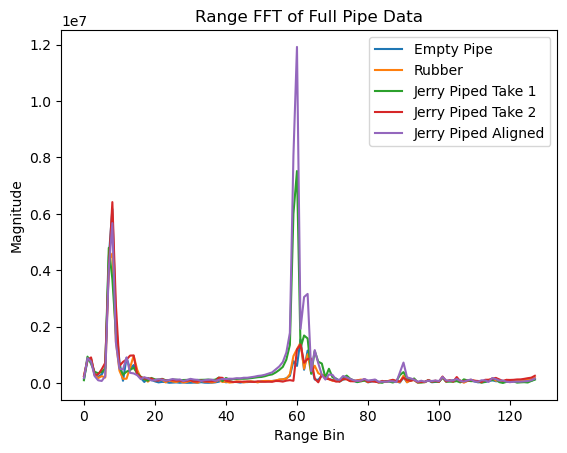

In [59]:
#plot full pipe data
plt.plot(abs(np.squeeze(np.sum(pipe_rfft[4],axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(rubber_rfft,axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(jerry_piped_rfft[0],axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(jerry_piped_rfft[1],axis=(0,2,1)))))
plt.plot(abs(np.squeeze(np.sum(jerry_pipe_aligned_rfft,axis=(0,2,1)))))
plt.legend(['Empty Pipe','Rubber', 'Jerry Piped Take 1', 'Jerry Piped Take 2', 'Jerry Piped Aligned'])
plt.xlabel('Range Bin')
plt.ylabel('Magnitude')
plt.title('Range FFT of Full Pipe Data')
plt.show()

In [65]:
aligned_jerry_data = np.fromfile(jerry_pipe_aligned_path, dtype=np.int16)
print(f"Total int16 samples: {len(aligned_jerry_data)}")
print(f"First 20 values: {aligned_jerry_data[:20]}")
print(f"Mean: {aligned_jerry_data.mean():.2f}, Std: {aligned_jerry_data.std():.2f}")

Total int16 samples: 246532
First 20 values: [16717 19540 16961 13600 12334 19744 21569 26157 27753  8293 27728 29793
 28518 28018  8250 29806  8236 29251 24933 25972]
Mean: -848.92, Std: 12477.73


In [66]:
# Your radar params from the lua config - fill these in
# Common IWR1843 config values:
num_tx = chirp_dict['num_tx'] # 3
num_rx = chirp_dict['num_rx'] # 4
samples_per_chirp = chirp_dict['samples_per_chirp']  # ADC samples
chirp_loops = chirp_dict['chirp_loops']        # chirps per frame (num_doppler_bins)

num_virtual_ant = num_tx * num_rx  # 12

samples_per_frame = num_virtual_ant * samples_per_chirp * chirp_loops * 2  # *2 for I+Q
print(f"Expected samples per frame: {samples_per_frame}")
print(f"Total samples: {len(aligned_jerry_data)}")
print(f"Number of frames: {len(aligned_jerry_data) / samples_per_frame:.2f}")  # should be close to integer

Expected samples per frame: 12288
Total samples: 246532
Number of frames: 20.06


In [69]:
samples_per_frame = num_virtual_ant * samples_per_chirp * chirp_loops * 2

num_frames = len(aligned_jerry_data) // samples_per_frame

print("Frames:", num_frames)

raw = aligned_jerry_data[:num_frames * samples_per_frame]

raw = raw.reshape(
    num_frames,
    chirp_loops,
    num_virtual_ant,
    samples_per_chirp * 2
)

iq = raw[..., 0::2] + 1j * raw[..., 1::2]

# reshape into standard format
iq = iq.transpose(0, 2, 1, 3)  # (frames, antennas, chirps, samples)
iq = iq.reshape(num_frames, num_virtual_ant, chirp_loops * samples_per_chirp)

Frames: 20


In [ ]:
# --- Range + Angle FFT ---
from streaming_base.processing.processing import beamform_2d

sph_pwr, phi, theta = beamform_2d(
    beat_freq_data=iq_frame,   # IMPORTANT: single frame only
    phi_s=0,
    phi_e=180,
    phi_res=2,
    theta_s=0,
    theta_e=90,
    theta_res=2,
    x_locs=x_locs[:,0],
    z_locs=z_locs[:,0],
    r_idxs=np.arange(0, 256),
    radar_params=cfg_radar
)

# --- Setup axes using your viz functions ---
sys.path.append(os.path.dirname(os.getcwd()))
from streaming_base.visualization import visualization  # adjust import to your file name

phi = np.linspace(0, np.pi, 64)   # 0 to 180 degrees in radians
r   = np.linspace(0, 10, 256)    # 0 to ~5m, adjust to your max range

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 5))
im = visualization.configure_ax_bf(ax, phi, r, vmin=0, vmax=power_cube.max() * 0.3)

# --- Scrub through frames with a slider ---
from matplotlib.widgets import Slider

ax_slider = fig.add_axes([0.2, 0.02, 0.6, 0.03])
slider = Slider(ax_slider, 'Frame', 0, num_frames - 1, valinit=0, valstep=1)

def update(val):
    frame = int(slider.val)

    Z = np.abs(angle_fft[frame])

    # ensure correct shape
    Z = Z[:len(phi), :len(r)]

    im.set_array(Z)

    im.set_clim(0, Z.max() + 1e-6)

    fig.canvas.draw_idle()

slider.on_changed(update)
update(0)
#plt.tight_layout()
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices